In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
from pathlib import Path

VIDEO_PATH = "/content/drive/MyDrive/Video/road.MP4"

video_file = Path(VIDEO_PATH)

print("Exists:", video_file.exists())
print("Path:", video_file)

Exists: True
Path: /content/drive/MyDrive/Video/road.MP4


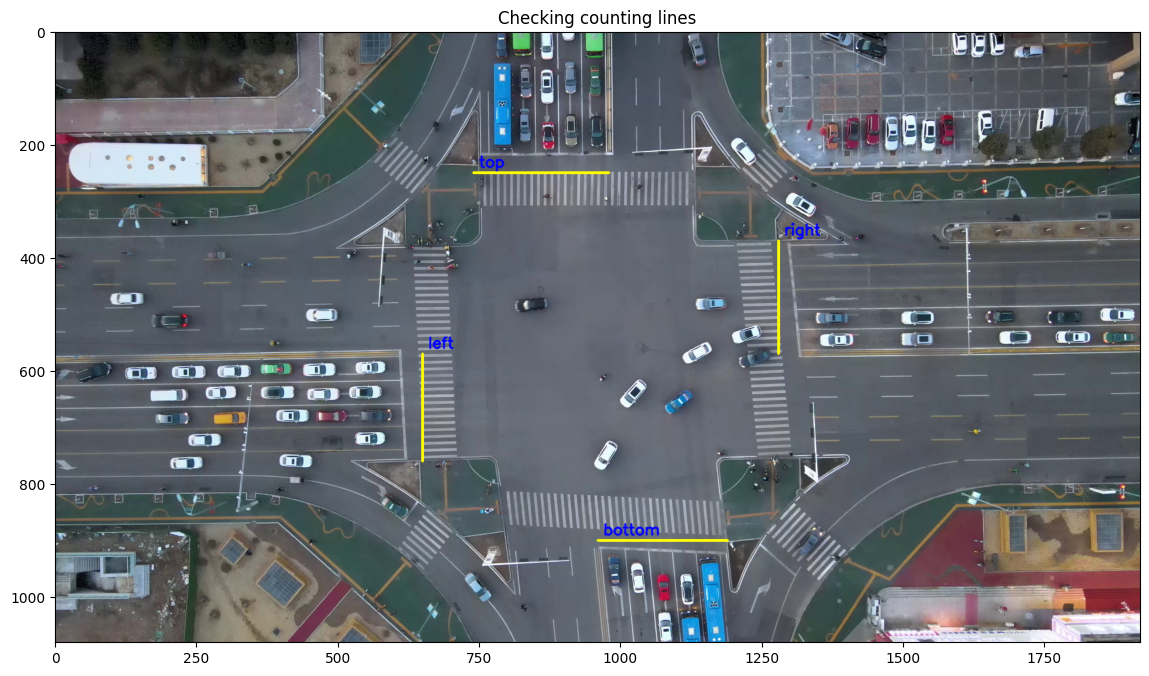

In [22]:
import cv2
import matplotlib.pyplot as plt

VIDEO_PATH = "/content/drive/MyDrive/Video/road.MP4"

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Unable to upload the first frame of the video")

test_lines = {
    "top": ((740, 250), (980, 250)),
    "bottom": ((960, 900), (1190, 900)),
    "left": ((650, 570), (650, 760)),
    "right": ((1280, 370), (1280, 570)),
}

for name, (p1, p2) in test_lines.items():
    cv2.line(frame, p1, p2, (0, 255, 255), 3)
    cv2.putText(
        frame,
        name,
        (p1[0] + 10, p1[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 0, 0),
        2,
        cv2.LINE_AA
    )

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
plt.title("Checking counting lines")
plt.axis("on")
plt.show()

In [23]:
!pip install -q ultralytics opencv-python pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.5 MB/s eta 0:00:00


In [24]:
from pathlib import Path
from collections import defaultdict
import math
import cv2
import pandas as pd
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/weights/best.pt"
VIDEO_PATH = "/content/drive/MyDrive/Video/road.MP4"
OUTPUT_DIR = Path("/content/drive/MyDrive/Q3_Counting")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRACKER_CONFIG = "bytetrack.yaml"
CONF_THRESHOLD = 0.25
IMAGE_SIZE = 640

SAVE_PREVIEW_VIDEO = False

COUNTS_CSV_PATH = OUTPUT_DIR / "traffic_counts_per_second.csv"
EVENTS_CSV_PATH = OUTPUT_DIR / "crossing_events.csv"
SUMMARY_CSV_PATH = OUTPUT_DIR / "traffic_summary.csv"

COUNT_LINES = {
    "top": {
        "p1": (740, 250),
        "p2": (980, 250),
        "direction": "down"
    },
    "bottom": {
        "p1": (960, 900),
        "p2": (1190, 900),
        "direction": "up"
    },
    "left": {
        "p1": (650, 570),
        "p2": (650, 760),
        "direction": "right"
    },
    "right": {
        "p1": (1280, 370),
        "p2": (1280, 570),
        "direction": "left"
    },
}

ALLOWED_CLASS_IDS = {0, 1, 2}

CLASS_ID_TO_NAME = {
    0: "bus",
    1: "car",
    2: "truck"
}

model = YOLO(MODEL_PATH)

def point_side_of_line(point, p1, p2):
    x, y = point
    x1, y1 = p1
    x2, y2 = p2
    return (x - x1) * (y2 - y1) - (y - y1) * (x2 - x1)

def crossed_line(prev_center, curr_center, p1, p2):
    prev_side = point_side_of_line(prev_center, p1, p2)
    curr_side = point_side_of_line(curr_center, p1, p2)

    if prev_side == 0 or curr_side == 0:
        return False

    return (prev_side > 0 and curr_side < 0) or (prev_side < 0 and curr_side > 0)

def movement_matches_expected(prev_center, curr_center, expected_direction):
    dx = curr_center[0] - prev_center[0]
    dy = curr_center[1] - prev_center[1]

    if expected_direction == "down":
        return dy > 0
    if expected_direction == "up":
        return dy < 0
    if expected_direction == "right":
        return dx > 0
    if expected_direction == "left":
        return dx < 0
    return False

def box_center_xyxy(x1, y1, x2, y2):
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Video loaded")
print("FPS:", fps)
print("Frame count:", frame_count)
print("Frame size:", width, "x", height)

track_history = {}
counted_track_line_pairs = set()

events = []
per_second_counts = defaultdict(lambda: {"top": 0, "bottom": 0, "left": 0, "right": 0})
total_counts = {"top": 0, "bottom": 0, "left": 0, "right": 0}

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(
        source=frame,
        persist=True,
        tracker=TRACKER_CONFIG,
        conf=CONF_THRESHOLD,
        imgsz=IMAGE_SIZE,
        verbose=False
    )

    result = results[0]

    if result.boxes is not None and result.boxes.id is not None:
        boxes_xyxy = result.boxes.xyxy.cpu().numpy()
        track_ids = result.boxes.id.cpu().numpy().astype(int)
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()

        for box, track_id, class_id, conf_score in zip(boxes_xyxy, track_ids, class_ids, confs):
            if class_id not in ALLOWED_CLASS_IDS:
                continue

            x1, y1, x2, y2 = box.tolist()
            curr_center = box_center_xyxy(x1, y1, x2, y2)

            if track_id in track_history:
                prev_center = track_history[track_id]["center"]

                for line_name, line_info in COUNT_LINES.items():
                    pair_key = (track_id, line_name)

                    if pair_key in counted_track_line_pairs:
                        continue

                    p1 = line_info["p1"]
                    p2 = line_info["p2"]
                    expected_direction = line_info["direction"]

                    if crossed_line(prev_center, curr_center, p1, p2):
                        if movement_matches_expected(prev_center, curr_center, expected_direction):
                            counted_track_line_pairs.add(pair_key)

                            second_idx = int(frame_idx / fps)
                            total_counts[line_name] += 1
                            per_second_counts[second_idx][line_name] += 1

                            events.append({
                                "frame": frame_idx,
                                "second": second_idx,
                                "track_id": int(track_id),
                                "class_id": int(class_id),
                                "class_name": CLASS_ID_TO_NAME.get(int(class_id), str(class_id)),
                                "confidence": float(conf_score),
                                "direction": line_name,
                                "center_x": float(curr_center[0]),
                                "center_y": float(curr_center[1]),
                            })

            track_history[track_id] = {
                "center": curr_center,
                "class_id": int(class_id)
            }

    frame_idx += 1

    if frame_idx % 200 == 0:
        print(f"Processed {frame_idx}/{frame_count} frames")

cap.release()

events_df = pd.DataFrame(events)

max_second = int(math.ceil(frame_count / fps))
rows = []

for second_idx in range(max_second):
    row = {
        "second": second_idx,
        "top": per_second_counts[second_idx]["top"],
        "bottom": per_second_counts[second_idx]["bottom"],
        "left": per_second_counts[second_idx]["left"],
        "right": per_second_counts[second_idx]["right"],
    }
    row["total"] = row["top"] + row["bottom"] + row["left"] + row["right"]
    rows.append(row)

counts_df = pd.DataFrame(rows)

summary_df = pd.DataFrame([{
    "top_total": total_counts["top"],
    "bottom_total": total_counts["bottom"],
    "left_total": total_counts["left"],
    "right_total": total_counts["right"],
    "grand_total": sum(total_counts.values()),
    "fps": fps,
    "frame_count": frame_count,
    "video_seconds": frame_count / fps
}])

events_df.to_csv(EVENTS_CSV_PATH, index=False)
counts_df.to_csv(COUNTS_CSV_PATH, index=False)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print("\nDone")
print("Counts CSV:", COUNTS_CSV_PATH)
print("Events CSV:", EVENTS_CSV_PATH)
print("Summary CSV:", SUMMARY_CSV_PATH)
print("\nSummary:")
print(summary_df)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Video loaded
FPS: 29.97002997002997
Frame count: 24908
Frame size: 1920 x 1080
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 228ms
Prepared 1 package in 424ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processed 200/24908 frames
Processed 400/24908 frames
Processed 600/24908 frames
Processed 800/24908 frames
Processed 1000/24908 frames
Processed 1200/24908 frames
Processed 1400/24908 frames
Processed 1600/24908 frames
Processed 1800/24908 frames
Proc

In [25]:
import pandas as pd

counts_df = pd.read_csv("/content/drive/MyDrive/Q3_Counting/traffic_counts_per_second.csv")
events_df = pd.read_csv("/content/drive/MyDrive/Q3_Counting/crossing_events.csv")
summary_df = pd.read_csv("/content/drive/MyDrive/Q3_Counting/traffic_summary.csv")

print("Traffic counts per second:")
display(counts_df.head(20))

print("Crossing events:")
display(events_df.head(20))

print("Summary:")
display(summary_df)

Traffic counts per second:


,second,top,bottom,left,right,total
0,0,0,1,1,1,3
1,1,0,0,0,2,2
2,2,0,0,0,0,0
3,3,0,0,0,2,2
4,4,0,0,1,0,1
5,5,0,0,0,1,1
6,6,0,0,0,1,1
7,7,0,0,2,1,3
8,8,1,0,0,1,2
9,9,0,0,0,1,1


Crossing events:


,frame,second,track_id,class_id,class_name,confidence,direction,center_x,center_y
0,4,0,81,1,car,0.695055,bottom,1343.440613,898.609406
1,25,0,57,1,car,0.907215,right,1278.486023,277.482422
2,27,0,70,1,car,0.827121,left,651.062836,877.217499
3,44,1,51,1,car,0.851472,right,1279.347595,558.831970
4,45,1,48,1,car,0.821917,right,1279.576660,514.288162
5,101,3,33,1,car,0.879354,right,1277.708801,560.673889
6,118,3,25,1,car,0.852547,right,1277.943298,516.738449
7,130,4,75,1,car,0.872438,left,650.329224,880.048340
8,172,5,11,1,car,0.844197,right,1278.863281,558.199524
9,184,6,9,1,car,0.859081,right,1278.790527,514.240555


Summary:


,top_total,bottom_total,left_total,right_total,grand_total,fps,frame_count,video_seconds
0,316,209,236,450,1211,29.97003,24908,831.096933


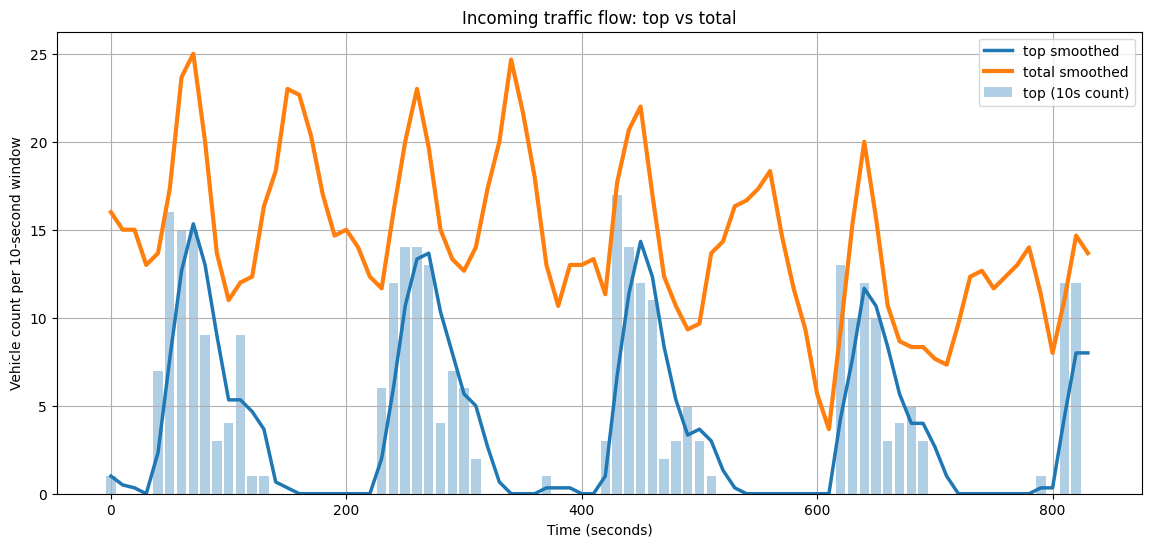

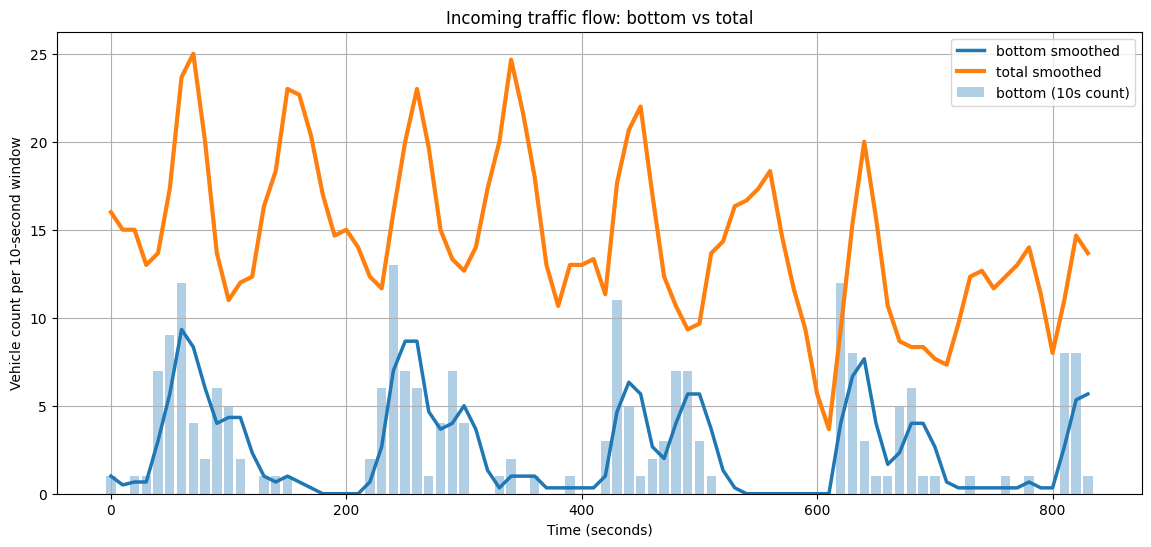

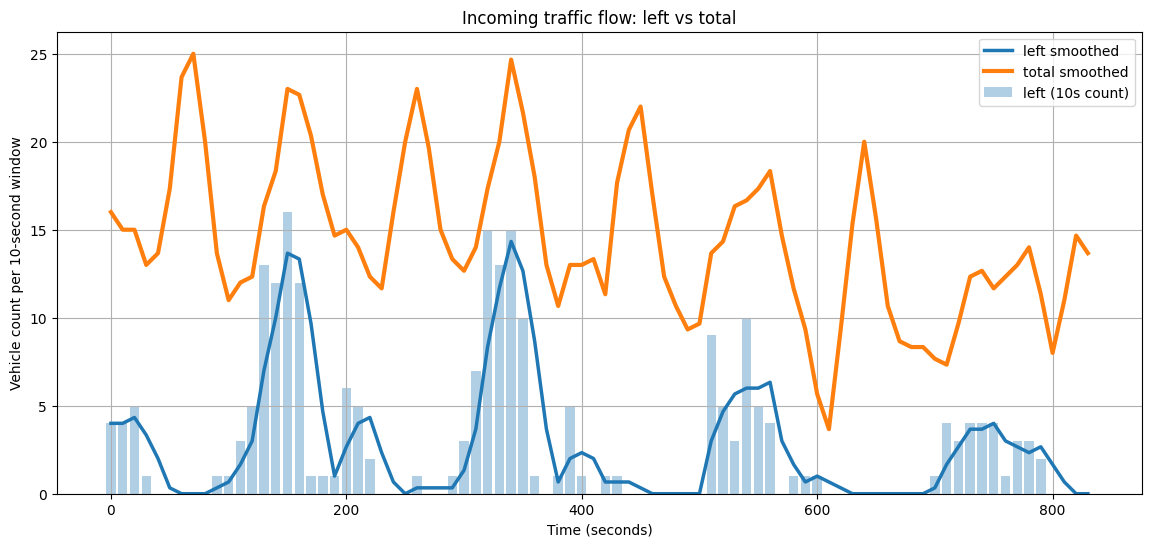

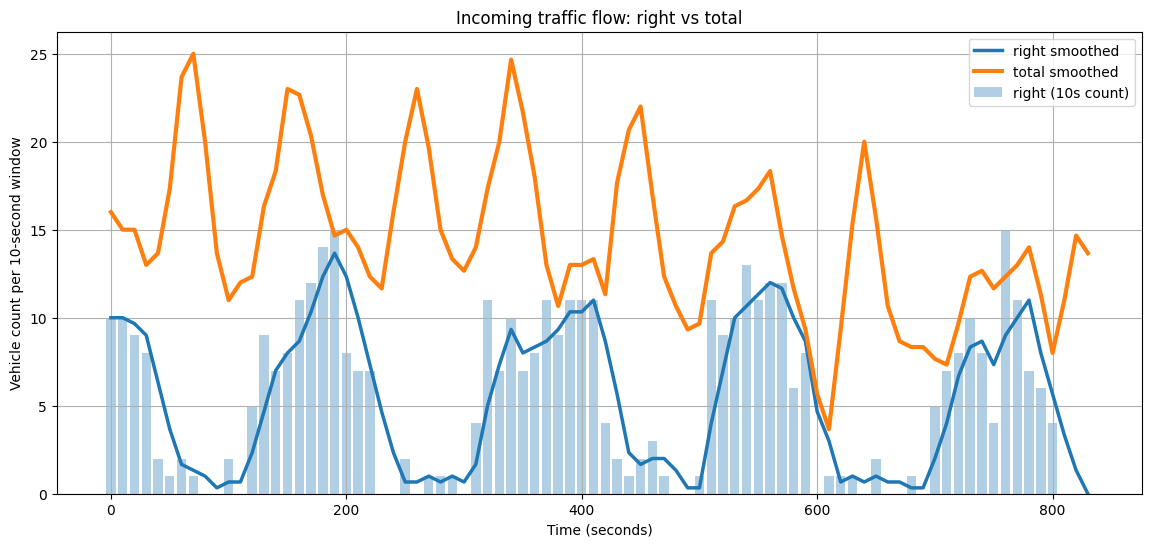

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

counts_df = pd.read_csv("/content/drive/MyDrive/Q3_Counting/traffic_counts_per_second.csv")

window_size_seconds = 10
rolling_window = 3

counts_df["time_bin"] = (counts_df["second"] // window_size_seconds) * window_size_seconds

agg_df = counts_df.groupby("time_bin", as_index=False).agg({
    "top": "sum",
    "bottom": "sum",
    "left": "sum",
    "right": "sum",
    "total": "sum"
})

direction_list = ["top", "bottom", "left", "right"]

for direction in direction_list:
    plot_df = agg_df.copy()
    plot_df[f"{direction}_smooth"] = plot_df[direction].rolling(window=rolling_window, min_periods=1).mean()
    plot_df["total_smooth"] = plot_df["total"].rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(14, 6))

    plt.bar(plot_df["time_bin"], plot_df[direction], width=8, alpha=0.35, label=f"{direction} (10s count)")
    plt.plot(plot_df["time_bin"], plot_df[f"{direction}_smooth"], linewidth=2.5, label=f"{direction} smoothed")
    plt.plot(plot_df["time_bin"], plot_df["total_smooth"], linewidth=3, label="total smoothed")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Vehicle count per 10-second window")
    plt.title(f"Incoming traffic flow: {direction} vs total")
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
import pandas as pd

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_second.csv"
OUTPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"

counts_df = pd.read_csv(INPUT_CSV)

window_size = 10

counts_df["time_bin"] = (counts_df["second"] // window_size) * window_size

agg_df = counts_df.groupby("time_bin", as_index=False).agg({
    "top": "sum",
    "bottom": "sum",
    "left": "sum",
    "right": "sum",
    "total": "sum"
})

agg_df = agg_df.rename(columns={"time_bin": "time_seconds"})
agg_df["time_step"] = range(len(agg_df))

agg_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Rows:", len(agg_df))
display(agg_df.head(20))

Saved: /content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv
Rows: 84


,time_seconds,top,bottom,left,right,total,time_step
0,0,1,1,4,10,16,0
1,10,0,0,4,10,14,1
2,20,0,1,5,9,15,2
3,30,0,1,1,8,10,3
4,40,7,7,0,2,16,4
5,50,16,9,0,1,26,5
6,60,15,12,0,2,29,6
7,70,15,4,0,1,20,7
8,80,9,2,0,0,11,8
9,90,3,6,1,0,10,9


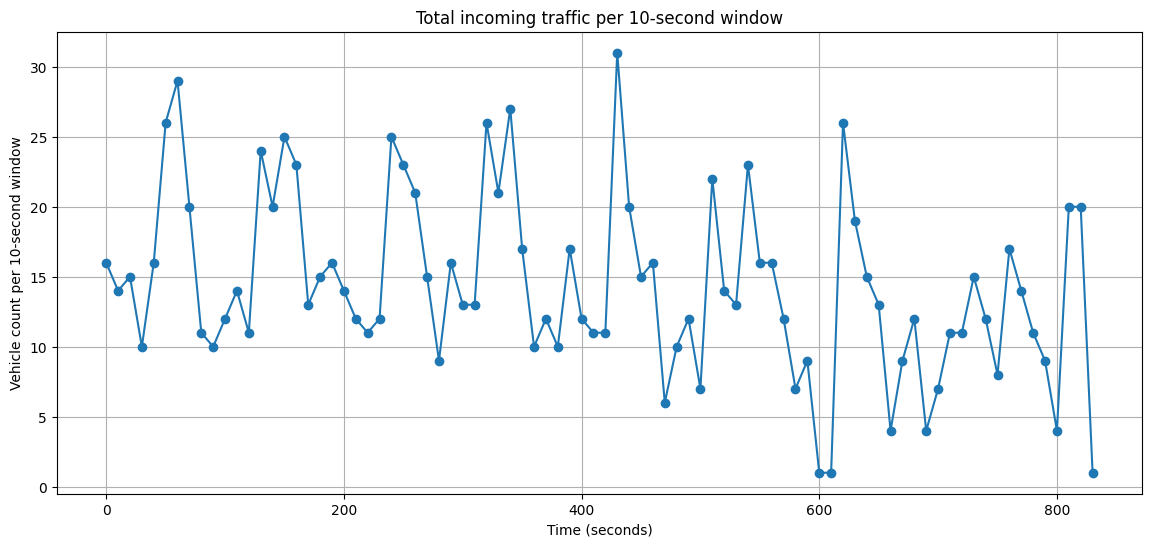

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"

agg_df = pd.read_csv(INPUT_CSV)

plt.figure(figsize=(14, 6))
plt.plot(agg_df["time_seconds"], agg_df["total"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Vehicle count per 10-second window")
plt.title("Total incoming traffic per 10-second window")
plt.grid(True)
plt.show()

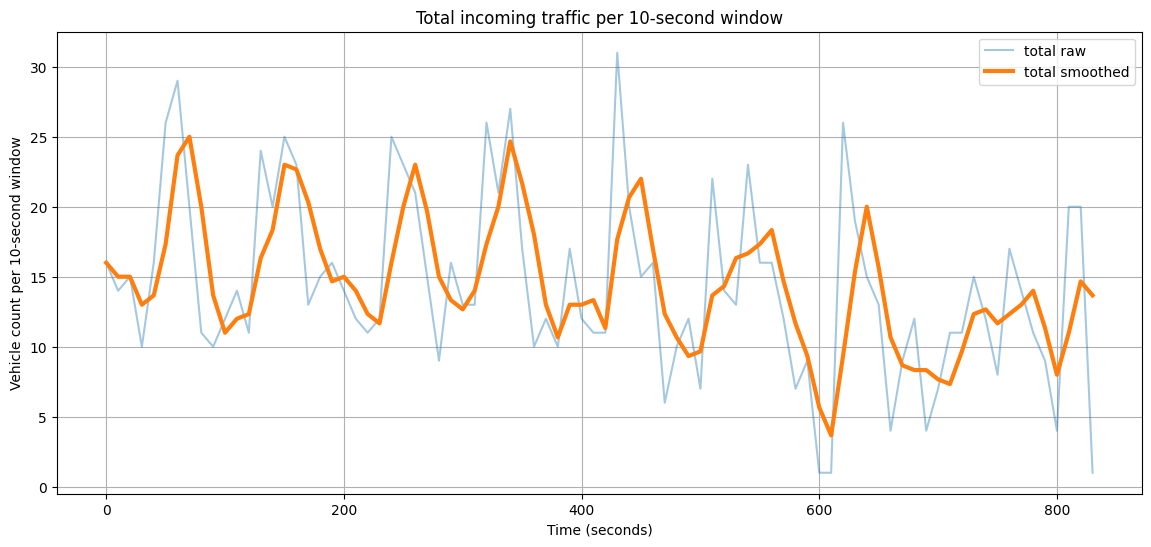

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"

agg_df = pd.read_csv(INPUT_CSV)

rolling_window = 3
agg_df["total_smooth"] = agg_df["total"].rolling(window=rolling_window, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(agg_df["time_seconds"], agg_df["total"], alpha=0.4, label="total raw")
plt.plot(agg_df["time_seconds"], agg_df["total_smooth"], linewidth=3, label="total smoothed")
plt.xlabel("Time (seconds)")
plt.ylabel("Vehicle count per 10-second window")
plt.title("Total incoming traffic per 10-second window")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
import pandas as pd

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"

agg_df = pd.read_csv(INPUT_CSV)

series_df = agg_df[["time_step", "time_seconds", "total"]].copy()

train_size = int(len(series_df) * 0.8)

train_df = series_df.iloc[:train_size].copy()
test_df = series_df.iloc[train_size:].copy()

print("Total rows:", len(series_df))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

display(train_df.head())
display(test_df.head())

Total rows: 84
Train rows: 67
Test rows: 17


,time_step,time_seconds,total
0,0,0,16
1,1,10,14
2,2,20,15
3,3,30,10
4,4,40,16


,time_step,time_seconds,total
67,67,670,9
68,68,680,12
69,69,690,4
70,70,700,7
71,71,710,11


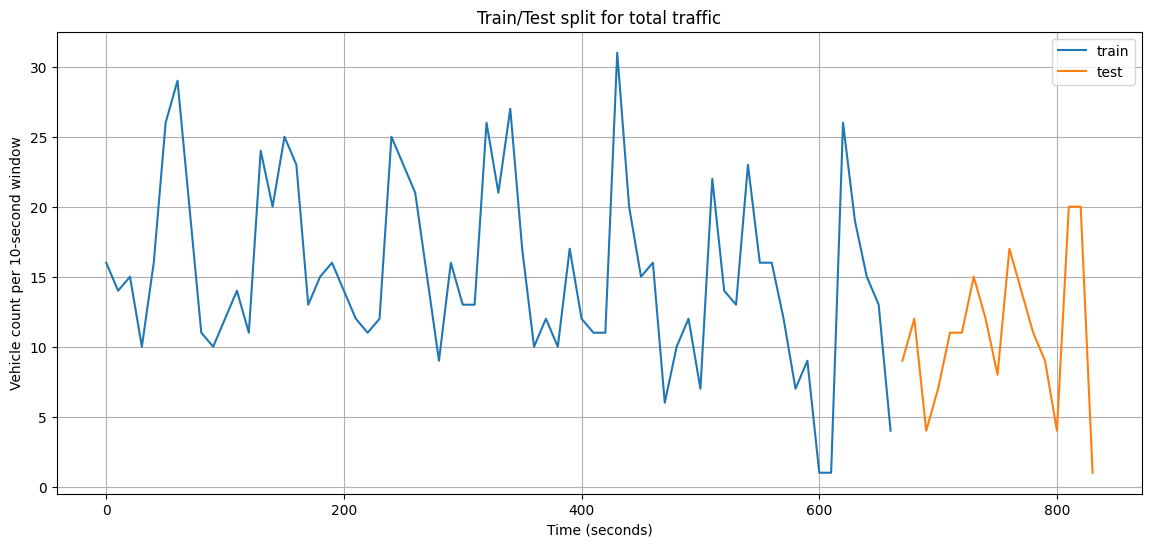

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(train_df["time_seconds"], train_df["total"], label="train")
plt.plot(test_df["time_seconds"], test_df["total"], label="test")
plt.xlabel("Time (seconds)")
plt.ylabel("Vehicle count per 10-second window")
plt.title("Train/Test split for total traffic")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
!pip install -q pandas numpy matplotlib scikit-learn statsmodels prophet tensorflow openpyxl

In [36]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/Q3_Forecasting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMNS = ["total", "top", "bottom", "left", "right"]

TRAIN_RATIO = 0.8
LSTM_LOOKBACK = 5
LSTM_EPOCHS = 80
LSTM_BATCH_SIZE = 8

In [37]:
df = pd.read_csv(INPUT_CSV)
print(df.head())
print("Rows:", len(df))

   time_seconds  top  bottom  left  right  total  time_step
0             0    1       1     4     10     16          0
1            10    0       0     4     10     14          1
2            20    0       1     5      9     15          2
3            30    0       1     1      8     10          3
4            40    7       7     0      2     16          4
Rows: 84


In [38]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred)
    }

def plot_train_test(train_df, test_df, target_col, title):
    plt.figure(figsize=(14, 6))
    plt.plot(train_df["time_seconds"], train_df[target_col], label="train")
    plt.plot(test_df["time_seconds"], test_df[target_col], label="test")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Vehicle count per 10-second window")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_predictions(train_df, test_df, target_col, pred_dict, title):
    plt.figure(figsize=(14, 6))
    plt.plot(train_df["time_seconds"], train_df[target_col], label="train")
    plt.plot(test_df["time_seconds"], test_df[target_col], label="actual test", linewidth=3)

    for model_name, y_pred in pred_dict.items():
        plt.plot(test_df["time_seconds"], y_pred, label=model_name)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Vehicle count per 10-second window")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_lstm_loss(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="train loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def build_naive_forecast(train_values, test_values):
    y_pred = []
    previous_value = train_values[-1]

    for actual_value in test_values:
        y_pred.append(previous_value)
        previous_value = actual_value

    return np.array(y_pred)

def build_arima_forecast(train_values, test_values, order=(3, 1, 1)):
    history = list(train_values)
    predictions = []

    for actual_value in test_values:
        model = ARIMA(history, order=order)
        fitted_model = model.fit()
        forecast = fitted_model.forecast(steps=1)[0]
        predictions.append(forecast)
        history.append(actual_value)

    return np.array(predictions)

def build_prophet_forecast(train_df, test_df, target_col):
    prophet_train = pd.DataFrame({
        "ds": pd.to_datetime(train_df["time_seconds"], unit="s"),
        "y": train_df[target_col].values
    })

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False
    )
    model.fit(prophet_train)

    future_df = pd.DataFrame({
        "ds": pd.to_datetime(test_df["time_seconds"], unit="s")
    })

    forecast_df = model.predict(future_df)
    y_pred = forecast_df["yhat"].values
    y_pred = np.clip(y_pred, 0, None)

    return y_pred, model, forecast_df

def create_lstm_sequences(series_array, lookback):
    X, y = [], []

    for i in range(len(series_array) - lookback):
        X.append(series_array[i:i + lookback])
        y.append(series_array[i + lookback])

    X = np.array(X)
    y = np.array(y)

    return X, y

def build_lstm_forecast(train_values, test_values, lookback=5, epochs=80, batch_size=8):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_values.reshape(-1, 1))

    X_train, y_train = create_lstm_sequences(train_scaled, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    model = Sequential([
        LSTM(32, activation="tanh", input_shape=(lookback, 1)),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping]
    )

    rolling_history = list(train_values[-lookback:])
    predictions = []

    for actual_value in test_values:
        input_array = np.array(rolling_history).reshape(-1, 1)
        input_scaled = scaler.transform(input_array)
        X_input = input_scaled.reshape((1, lookback, 1))

        pred_scaled = model.predict(X_input, verbose=0)[0][0]
        pred_value = scaler.inverse_transform(np.array([[pred_scaled]]))[0][0]
        pred_value = max(0, pred_value)

        predictions.append(pred_value)
        rolling_history.pop(0)
        rolling_history.append(actual_value)

    return np.array(predictions), model, history

In [39]:
def run_forecasting_for_target(df, target_col):
    print("=" * 80)
    print(f"TARGET: {target_col}")
    print("=" * 80)

    series_df = df[["time_step", "time_seconds", target_col]].copy()

    train_size = int(len(series_df) * TRAIN_RATIO)
    train_df = series_df.iloc[:train_size].copy()
    test_df = series_df.iloc[train_size:].copy()

    train_values = train_df[target_col].values.astype(float)
    test_values = test_df[target_col].values.astype(float)

    plot_train_test(
        train_df,
        test_df,
        target_col,
        title=f"Train/Test split for {target_col}"
    )

    results = []

    baseline_pred = build_naive_forecast(train_values, test_values)
    baseline_metrics = evaluate_forecast(test_values, baseline_pred)
    results.append({
        "Target": target_col,
        "Model": "Baseline",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"]
    })

    arima_pred = build_arima_forecast(train_values, test_values, order=(3, 1, 1))
    arima_metrics = evaluate_forecast(test_values, arima_pred)
    results.append({
        "Target": target_col,
        "Model": "ARIMA",
        "MAE": arima_metrics["MAE"],
        "RMSE": arima_metrics["RMSE"]
    })

    prophet_pred, prophet_model, prophet_forecast_df = build_prophet_forecast(train_df, test_df, target_col)
    prophet_metrics = evaluate_forecast(test_values, prophet_pred)
    results.append({
        "Target": target_col,
        "Model": "Prophet",
        "MAE": prophet_metrics["MAE"],
        "RMSE": prophet_metrics["RMSE"]
    })

    lstm_pred, lstm_model, lstm_history = build_lstm_forecast(
        train_values,
        test_values,
        lookback=LSTM_LOOKBACK,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH_SIZE
    )
    lstm_metrics = evaluate_forecast(test_values, lstm_pred)
    results.append({
        "Target": target_col,
        "Model": "LSTM",
        "MAE": lstm_metrics["MAE"],
        "RMSE": lstm_metrics["RMSE"]
    })

    plot_predictions(
        train_df,
        test_df,
        target_col,
        pred_dict={
            "Baseline": baseline_pred,
            "ARIMA": arima_pred,
            "Prophet": prophet_pred,
            "LSTM": lstm_pred
        },
        title=f"Forecast comparison for {target_col}"
    )

    plot_lstm_loss(
        lstm_history,
        title=f"LSTM training history for {target_col}"
    )

    target_results_df = pd.DataFrame(results)
    print(target_results_df)

    return {
        "results_df": target_results_df,
        "train_df": train_df,
        "test_df": test_df,
        "predictions": {
            "Baseline": baseline_pred,
            "ARIMA": arima_pred,
            "Prophet": prophet_pred,
            "LSTM": lstm_pred
        }
    }

TARGET: total


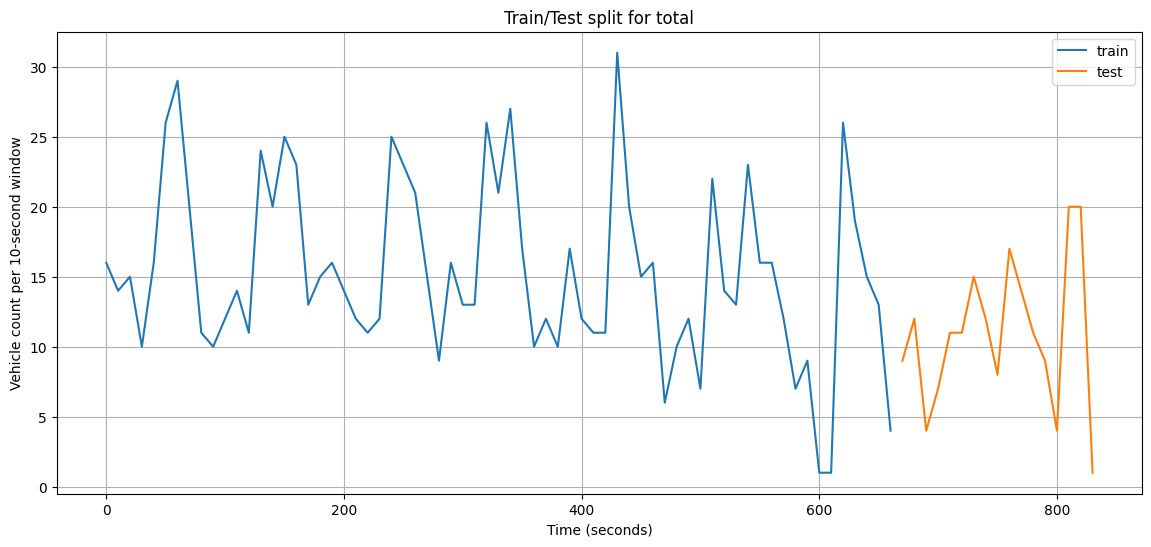

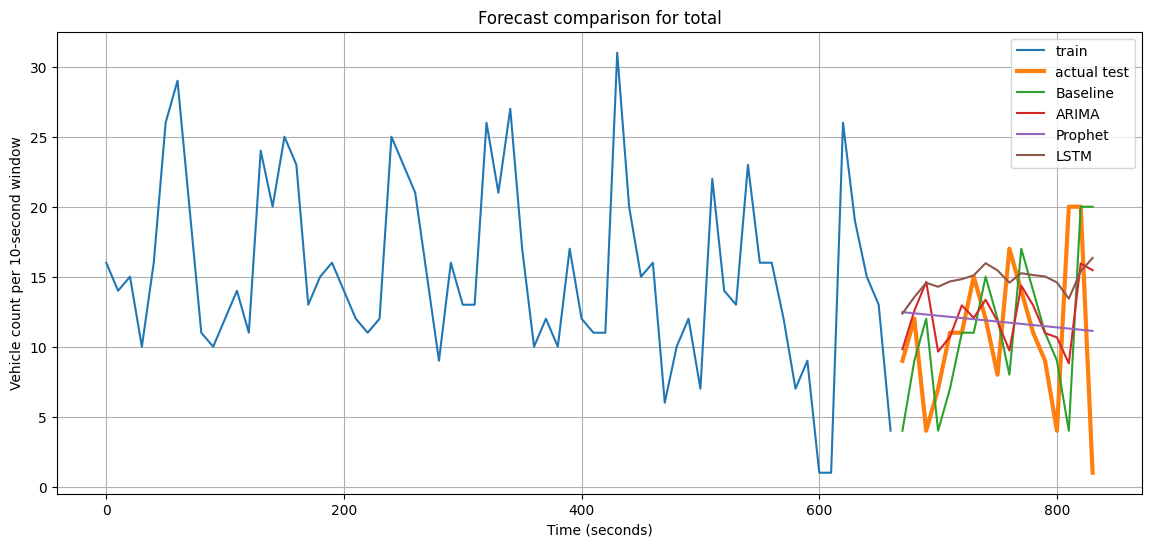

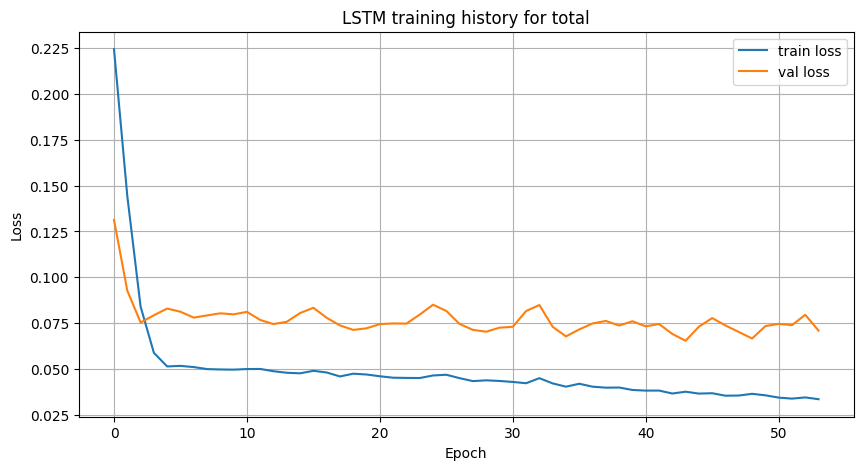

  Target     Model       MAE      RMSE
0  total  Baseline  5.352941  7.312359
1  total     ARIMA  4.292271  5.971254
2  total   Prophet  4.245335  5.337358
3  total      LSTM  5.453446  6.644224


In [40]:
total_output = run_forecasting_for_target(df, "total")

TARGET: top


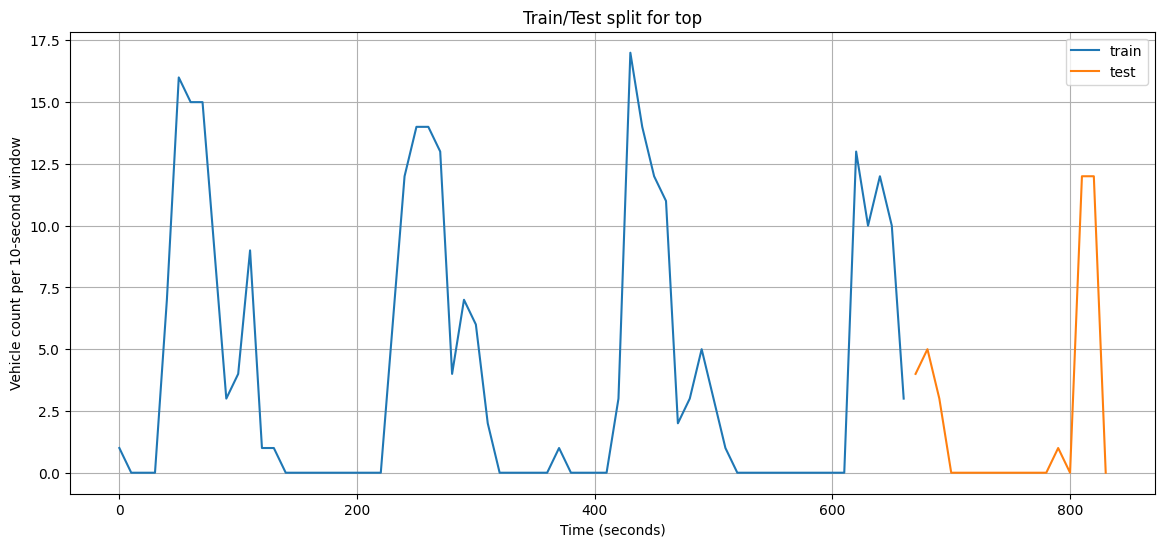

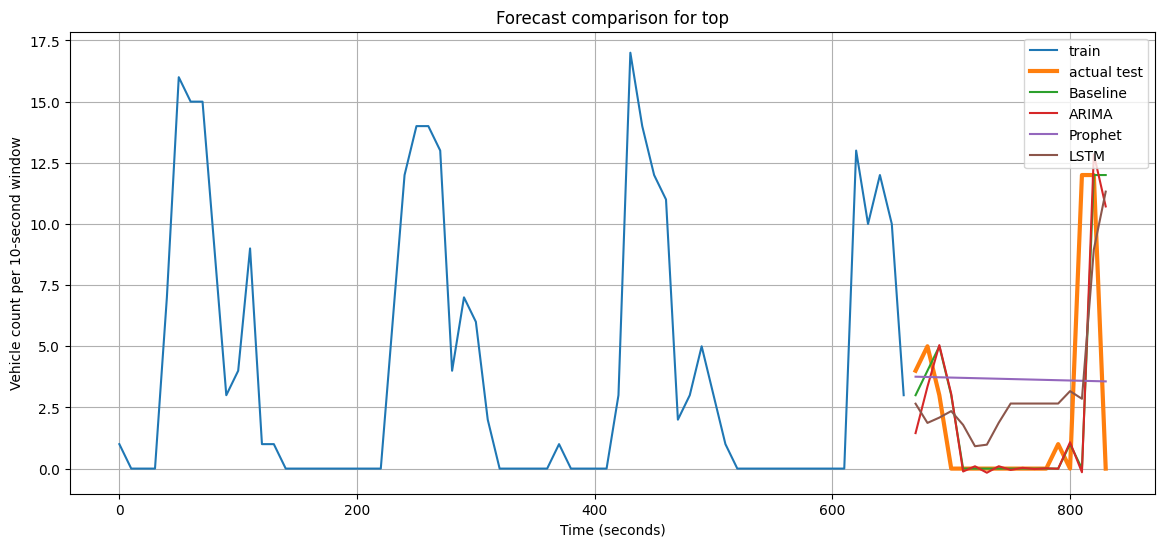

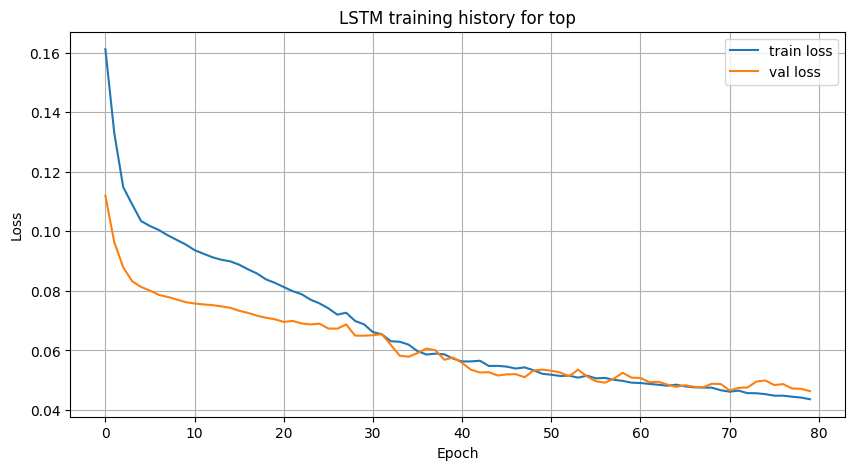

  Target     Model       MAE      RMSE
0    top  Baseline  1.941176  4.235703
1    top     ARIMA  2.099977  4.117222
2    top   Prophet  3.641117  4.185266
3    top      LSTM  3.075142  4.120864
TARGET: bottom


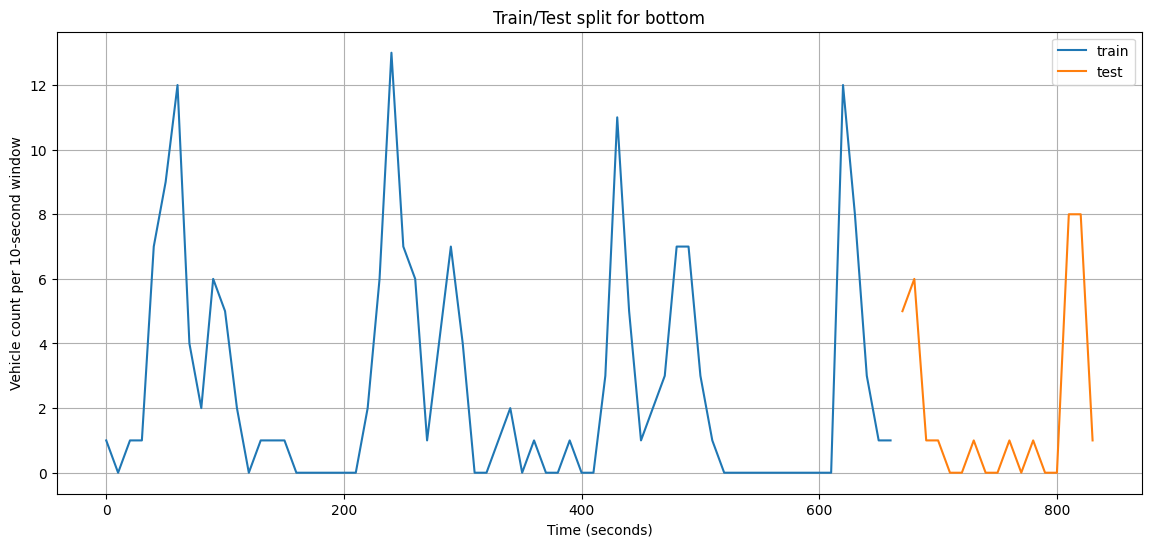

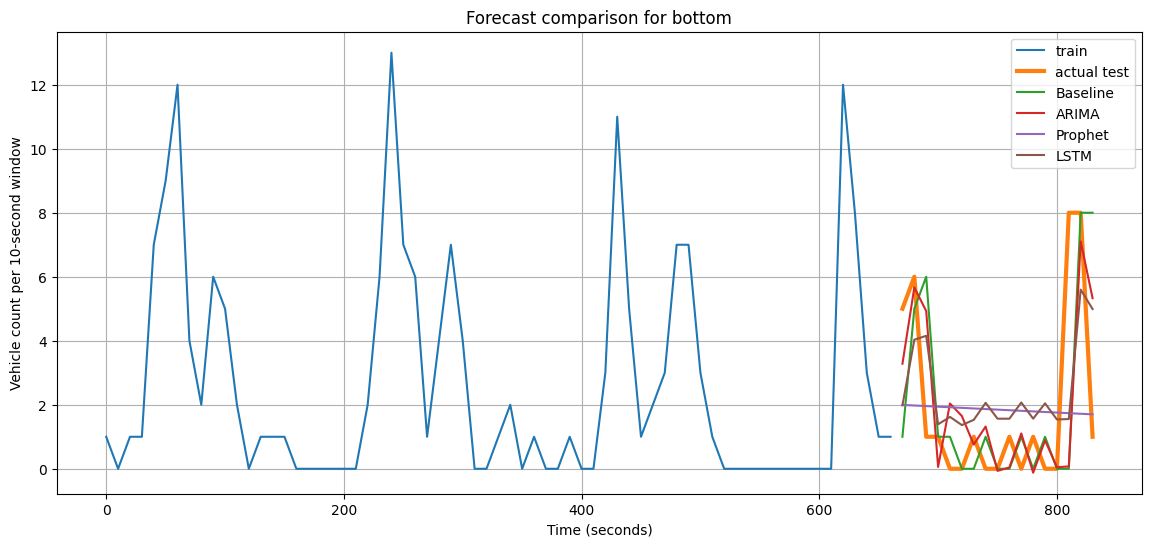

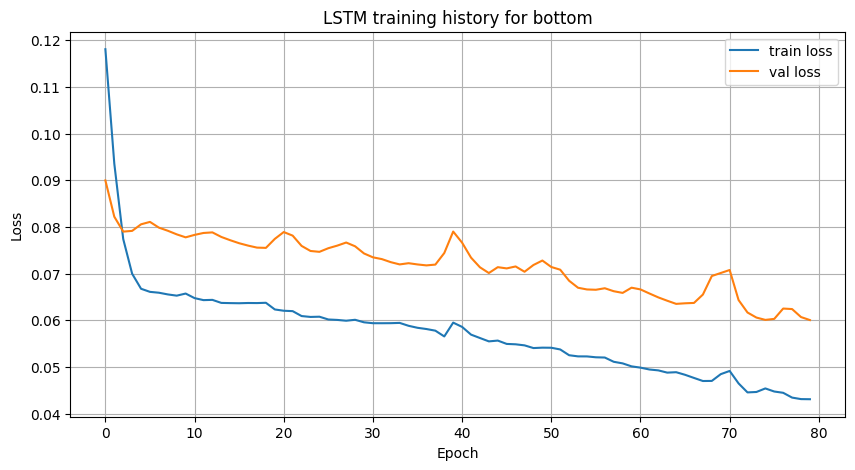

   Target     Model       MAE      RMSE
0  bottom  Baseline  1.882353  3.086975
1  bottom     ARIMA  1.735949  2.596693
2  bottom   Prophet  2.209357  2.786545
3  bottom      LSTM  2.076223  2.535430
TARGET: left


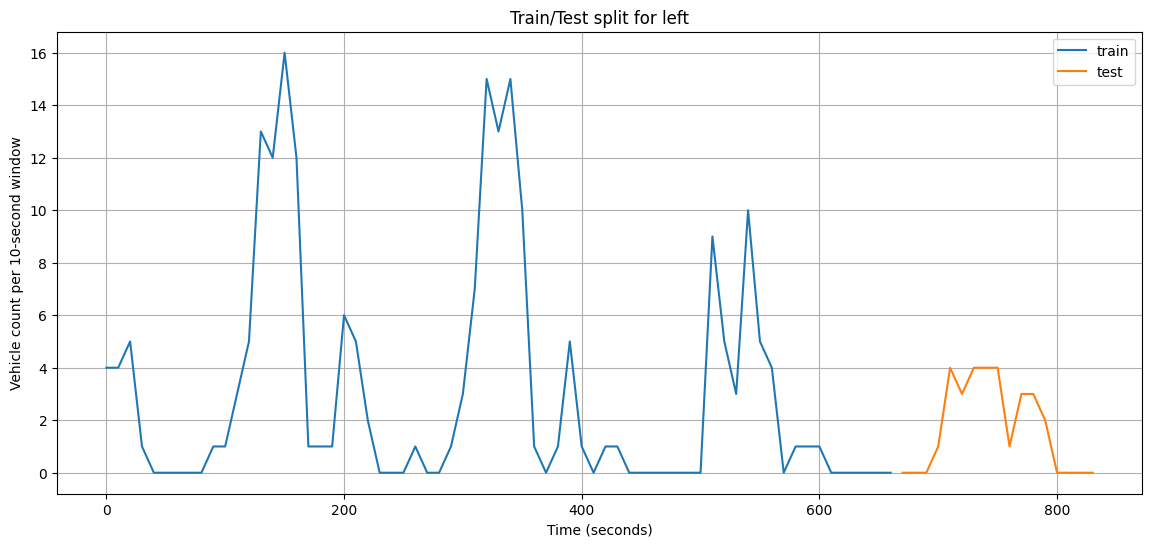

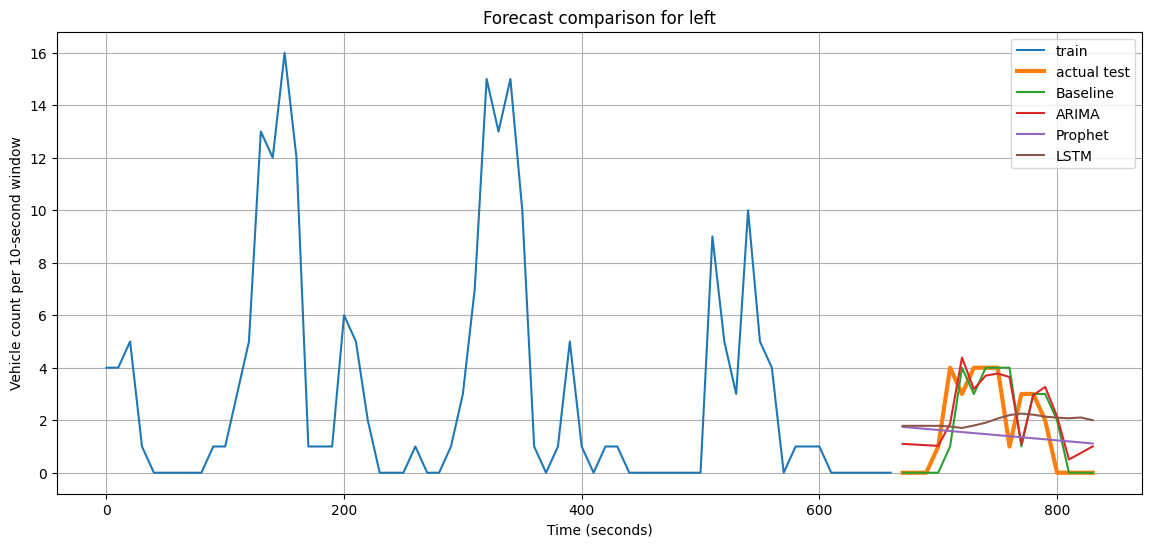

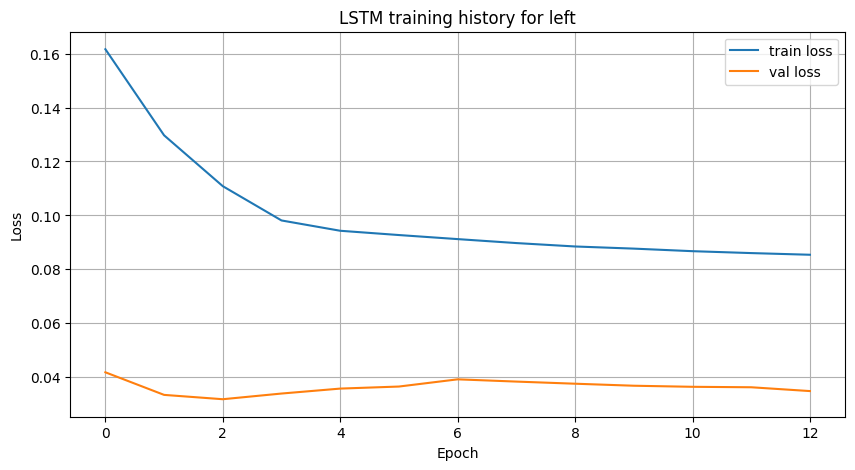

  Target     Model       MAE      RMSE
0   left  Baseline  0.823529  1.328422
1   left     ARIMA  1.080380  1.315030
2   left   Prophet  1.550075  1.680950
3   left      LSTM  1.591618  1.708482
TARGET: right


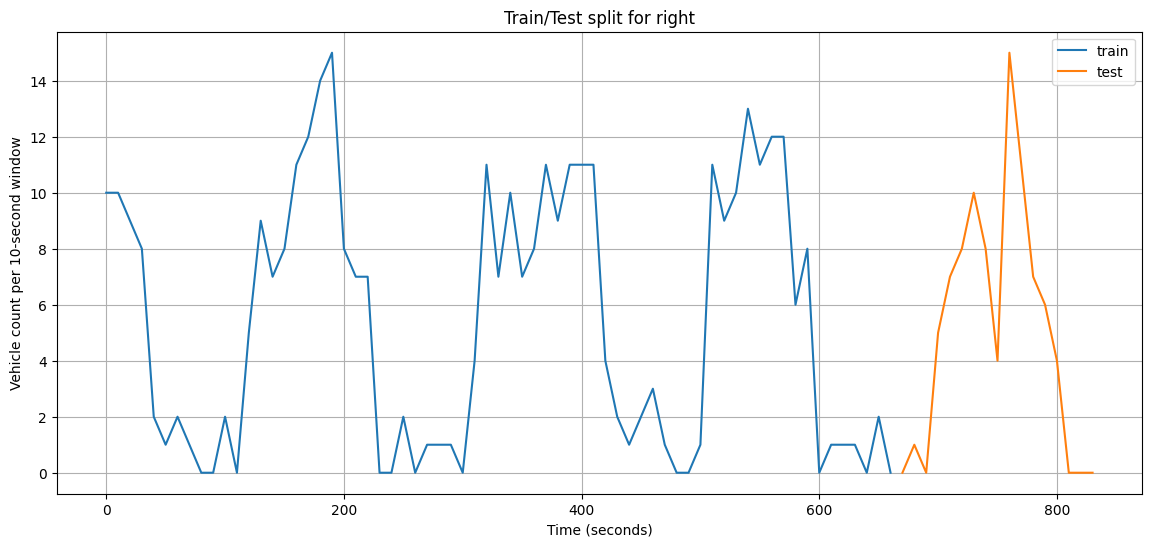

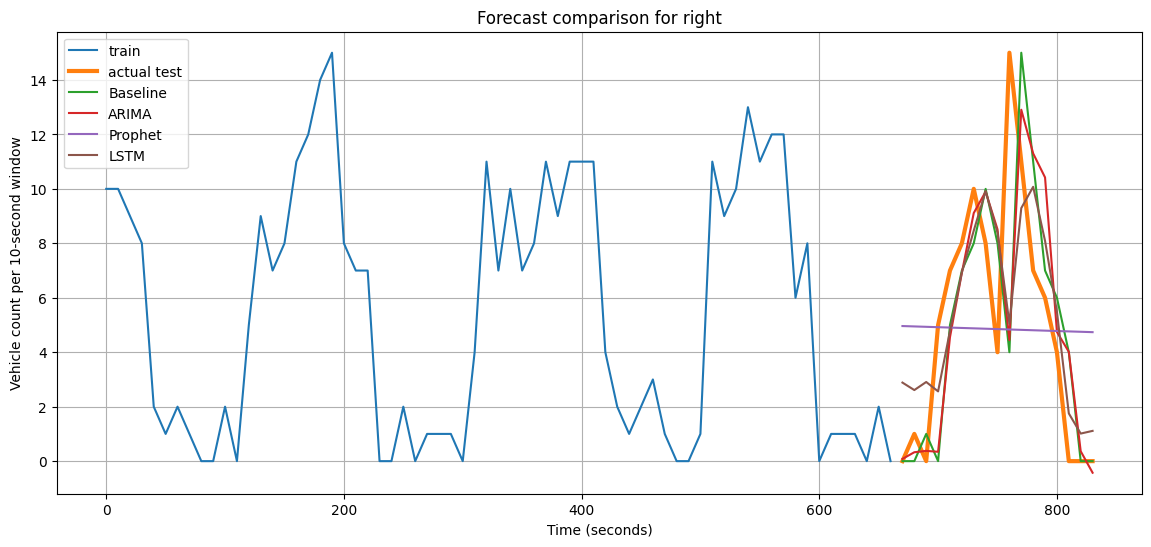

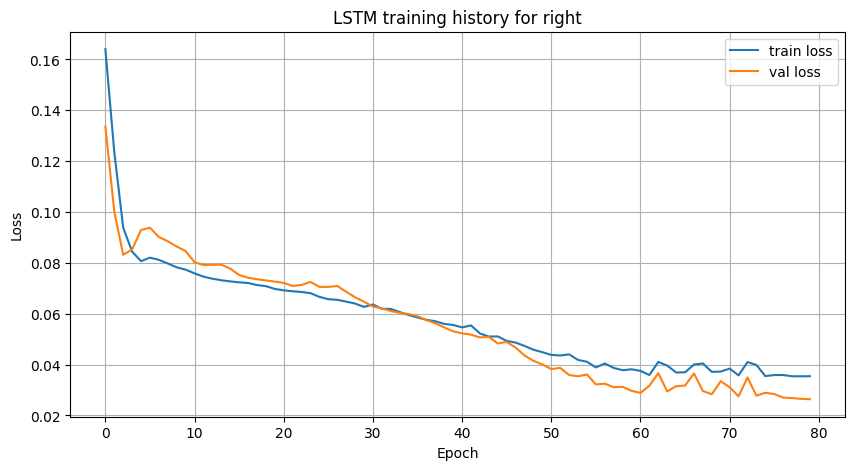

  Target     Model       MAE      RMSE
0  right  Baseline  2.588235  3.678235
1  right     ARIMA  2.549666  3.632005
2  right   Prophet  3.706488  4.415794
3  right      LSTM  2.538477  3.253263


In [41]:
all_results = [total_output["results_df"]]

for target_col in ["top", "bottom", "left", "right"]:
    output = run_forecasting_for_target(df, target_col)
    all_results.append(output["results_df"])

In [42]:
final_results_df = pd.concat(all_results, ignore_index=True)
final_results_df = final_results_df.sort_values(["Target", "RMSE", "MAE"]).reset_index(drop=True)

display(final_results_df)

final_results_path = OUTPUT_DIR / "forecasting_model_comparison.csv"
final_results_df.to_csv(final_results_path, index=False)

print("Saved:", final_results_path)

,Target,Model,MAE,RMSE
0,bottom,LSTM,2.076223,2.535430
1,bottom,ARIMA,1.735949,2.596693
2,bottom,Prophet,2.209357,2.786545
3,bottom,Baseline,1.882353,3.086975
4,left,ARIMA,1.080380,1.315030
5,left,Baseline,0.823529,1.328422
6,left,Prophet,1.550075,1.680950
7,left,LSTM,1.591618,1.708482
8,right,LSTM,2.538477,3.253263
9,right,ARIMA,2.549666,3.632005


Saved: /content/drive/MyDrive/Q3_Forecasting/forecasting_model_comparison.csv


In [43]:
best_models_df = final_results_df.sort_values(["Target", "RMSE", "MAE"]).groupby("Target", as_index=False).first()
display(best_models_df)

best_models_path = OUTPUT_DIR / "best_forecasting_models.csv"
best_models_df.to_csv(best_models_path, index=False)

print("Saved:", best_models_path)

,Target,Model,MAE,RMSE
0,bottom,LSTM,2.076223,2.535430
1,left,ARIMA,1.080380,1.315030
2,right,LSTM,2.538477,3.253263
3,top,ARIMA,2.099977,4.117222
4,total,Prophet,4.245335,5.337358


Saved: /content/drive/MyDrive/Q3_Forecasting/best_forecasting_models.csv


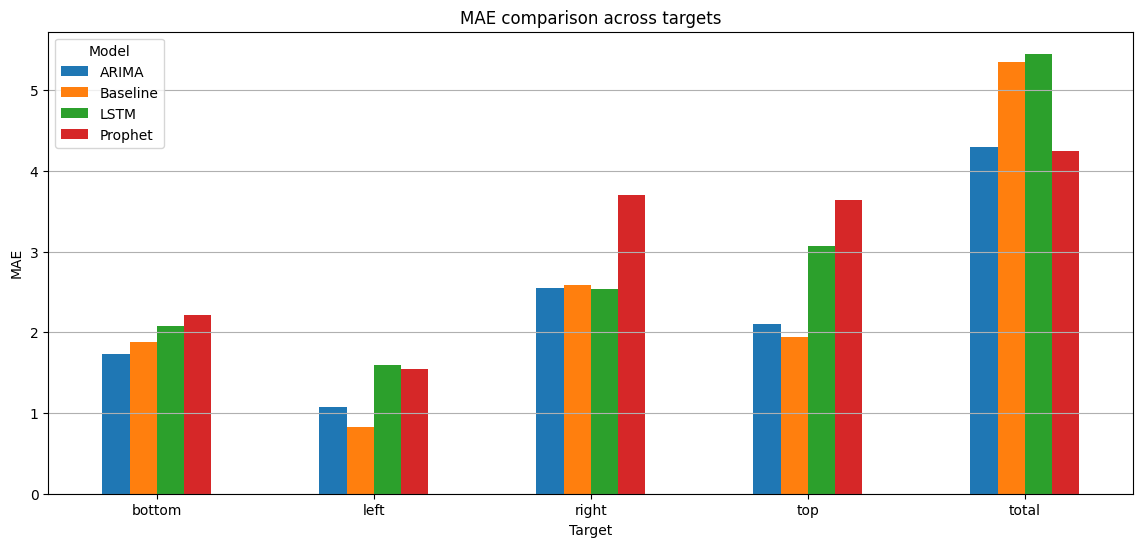

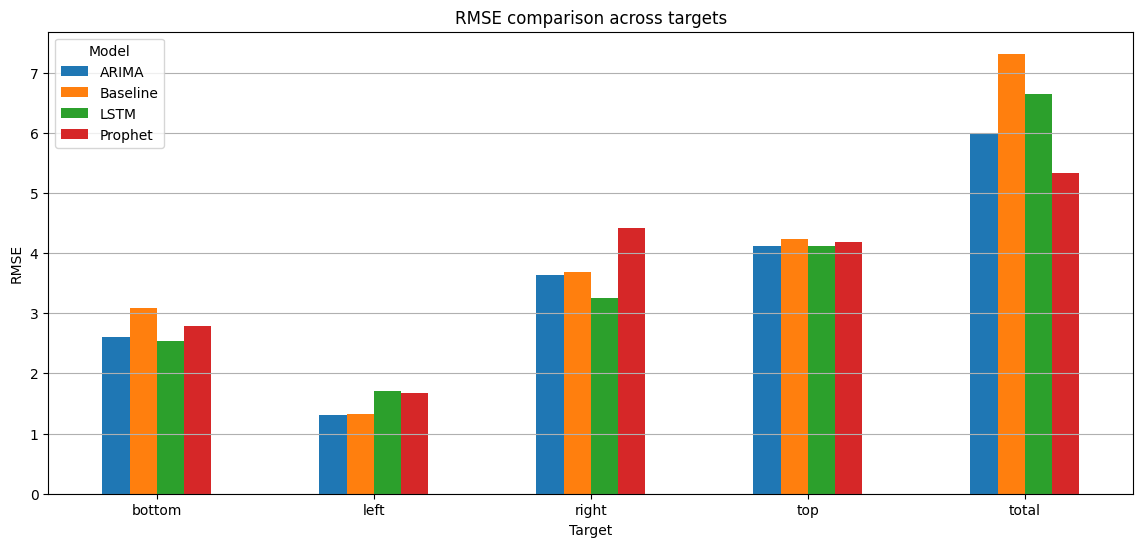

In [44]:
import matplotlib.pyplot as plt

for metric_name in ["MAE", "RMSE"]:
    plt.figure(figsize=(14, 6))

    pivot_df = final_results_df.pivot(index="Target", columns="Model", values=metric_name)
    pivot_df.plot(kind="bar", ax=plt.gca())

    plt.title(f"{metric_name} comparison across targets")
    plt.ylabel(metric_name)
    plt.grid(True, axis="y")
    plt.xticks(rotation=0)
    plt.legend(title="Model")
    plt.show()